# Regime-Stratified Sensitivity Analysis — Level 5L6 (isothermal)

Sensitivity of the L5L6 model (defective oxide L3 + defective metal L4 + surface kinetics L6)
**conditioned on the rate-limiting regime**, run **isothermally** at several temperatures.

## Regimes — surface / oxide / metal

`regime = argmax` of the flux-weighted resistance fractions
(`frac_surface`, `frac_oxide`, `frac_metal`), all three of which are **series** resistances.

> **Note — the parallel path is computed but not part of the label.**
> `calculate_full_model_flux_L346_v2` does model the defect bypass (pinhole / crack /
> grain-boundary, each with its own permeance), and `flux_intact` / `flux_defect` are recorded.
> But unlike the L5 study — where `defect` is a peer regime — the L5L6 label is argmax over the
> three series terms only. A run whose flux is mostly through pinholes is still labelled by
> whichever series resistance dominates the *intact* path. So an L5L6 `metal` cluster is NOT
> the same population as an L5 `metal` cluster; do not compare the two directly.

## Why isothermal

With `temperature` varying it monopolises the variance of log10(flux). A dummy-parameter test
on varying-T L5L6 clusters put temperature at **3.4-4.3x** the noise floor and, in the metal
cluster, **nothing else above 1.0x** — the runner-up (`crack_thickness_factor`) scored 0.84x,
below a random input the model never saw. L5L6 is worse than L5 here because it spreads 36
parameters over the residual variance instead of 28.

Sampling harder does not help: the floor is flat in n (0.085 at n=400, 0.092 at n=1500),
because delta's bias for an irrelevant input does not shrink with sample size. Pinning the
temperature is what lets the remaining 35 parameters compete.

Every result table carries a **`floor`** column (max delta over the dummy inputs) and
**`delta_over_floor`**. **A value at or below 1.0 is not resolved.**

> **Caveat for `theta`:** temperature does *not* dominate that metric (1.54x oxide, 0.88x
> metal), because theta is bounded [0,1] and analysed linearly. `K_eq_ref` and `H_eq` — the
> actual surface-kinetics parameters — do surface there. So theta was the one L5L6 output the
> varying-T run handled reasonably.

## Targeting

Presets are what create the study: an untargeted sweep yields essentially no surface-limited
rows. Yields measured at fixed temperature (250-draw probes) — note the surface yield more than
doubles across the range, so draw counts are sized per temperature:

| T | surface | oxide | metal |
|---|---|---|---|
| 773 K | 23.2% | 78.0% | 77.2% |
| 1073 K | 47.6% | 83.6% | 85.2% |
| 1273 K | 56.8% | 82.0% | 86.4% |

Run with the **`mace_env`** kernel (SALib pinned to 1.5.0).

In [1]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import calculations.sensitivity as sens
importlib.reload(sens)
from calculations.config.model_config import (
    SUGGESTED_RANGES_LEVEL5L6, REGIME_PRESETS, DEFAULT_SWEEP_TEMPERATURES, ACTIVE_STUDY
)
from calculations.sensitivity import (
    REGIME_LABELS, REGIME_SA_METRICS, LOG_METRICS_DEFAULT, presets_without,
    level5L6_model_wrapper, run_targeted_regime_scans, load_regime_scans,
    plot_regime_exploration, givendata_sensitivity_by_regime, summarize_givendata,
    plot_givendata_results, regime_comparison_matrix, plot_regime_comparison_heatmap,
    plot_regime_geometry
)

# temperature is PINNED, not sampled -> it leaves the SA input set entirely
PRESETS = presets_without(REGIME_PRESETS, 'temperature')
PARAMS  = [p for p in SUGGESTED_RANGES_LEVEL5L6 if p != 'temperature']
print(f"study: {ACTIVE_STUDY}")
print(f"{len(PARAMS)} sampled parameters (temperature pinned); regimes: {REGIME_LABELS}")

study: Guo_etal_2025_316L
35 sampled parameters (temperature pinned); regimes: ('surface', 'oxide', 'metal')


In [3]:
# === Run configuration ========================================================
SEED         = 42
TEMPERATURES = list(DEFAULT_SWEEP_TEMPERATURES)      # 773 / 1073 / 1273 K
METRICS      = REGIME_SA_METRICS                     # ['flux', 'permeability', 'theta']
TOP_K        = 8

# Draw counts are no longer precomputed from a cached yield table.
# Passing N_per_regime=None makes run_targeted_regime_scans probe each
# preset and size the run from the yield it actually observes, which
# stays correct if a range, a preset or the active study changes.
N_BY_T = {T: None for T in TEMPERATURES}

RESULTS_DIR     = "sa_results"
FORCE_RECOMPUTE = False
os.makedirs(RESULTS_DIR, exist_ok=True)


## Phase 1 — Targeted per-regime scans, one set per temperature

Cached to `sa_results/scans/T<K>/scan_<regime>.csv`. The cache is only reused when every file
holds exactly the draw count currently requested — existence alone would silently serve a
previous configuration.

In [4]:
def cache_is_valid(paths, n_expected):
    """Reusable only if every scan exists, and matches the count if one was asked for.

    With auto-sizing `n_expected` is None: the draw count is decided by the probe
    at run time, so existence is all that can be checked. Set FORCE_RECOMPUTE to
    re-probe and re-scan.
    """
    for r, p in paths.items():
        if not os.path.exists(p):
            return False, f"{os.path.basename(p)} missing"
        if n_expected is None:
            continue
        n_have = len(pd.read_csv(p, usecols=[0]))
        if n_have != n_expected[r]:
            return False, (f"{os.path.basename(p)} holds {n_have} draws but config "
                           f"asks for {n_expected[r]}")
    return True, "every scan matches the requested draw counts"


clusters_T, scans_T, yields_T = {}, {}, {}

for T in TEMPERATURES:
    scan_dir = os.path.join(RESULTS_DIR, "scans", f"T{int(T)}")
    os.makedirs(scan_dir, exist_ok=True)
    paths = {r: os.path.join(scan_dir, f"scan_{r}.csv") for r in REGIME_LABELS}
    reusable, why = cache_is_valid(paths, N_BY_T[T])

    print(f"\n{'='*70}\nT = {T:.0f} K\n{'='*70}")
    if (not FORCE_RECOMPUTE) and reusable:
        print(f"  loading cached scans ({why})")
        cl, sc, _ = load_regime_scans(scan_dir, regimes=REGIME_LABELS)
        yl = {r: len(cl[r]) / len(sc[r]) for r in cl}
    else:
        print("  recomputing —", "FORCE_RECOMPUTE is set" if FORCE_RECOMPUTE else why)
        cl, sc, _, yl = run_targeted_regime_scans(
            N_per_regime=N_BY_T[T], regimes=REGIME_LABELS,
            presets=PRESETS, wrapper=level5L6_model_wrapper,
            fixed_params={'temperature': T},
            seed=SEED, save_dir=scan_dir, verbose=False)
    clusters_T[T], scans_T[T], yields_T[T] = cl, sc, yl
    print("  clusters:", {r: len(cl[r]) for r in REGIME_LABELS})
    print("  yields:  ", {r: f"{yl[r]*100:.1f}%" for r in REGIME_LABELS})

master = pd.concat(
    [pd.concat(clusters_T[T].values()).assign(temperature_K=T) for T in TEMPERATURES],
    ignore_index=True)
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print(f"\nmaster_clusters.csv: {len(master)} rows")


T = 773 K
  recomputing — scan_surface.csv missing
  saved scan -> sa_results/scans/T773/scan_surface.csv
  saved scan -> sa_results/scans/T773/scan_oxide.csv
  saved scan -> sa_results/scans/T773/scan_metal.csv
  clusters: {'surface': 1801, 'oxide': 1739, 'metal': 1719}
  yields:   {'surface': '43.8%', 'oxide': '1.6%', 'metal': '97.2%'}

T = 1073 K
  recomputing — scan_surface.csv missing
  saved scan -> sa_results/scans/T1073/scan_surface.csv
  saved scan -> sa_results/scans/T1073/scan_oxide.csv
  saved scan -> sa_results/scans/T1073/scan_metal.csv
  clusters: {'surface': 1748, 'oxide': 1654, 'metal': 1693}
  yields:   {'surface': '77.4%', 'oxide': '23.0%', 'metal': '93.4%'}

T = 1273 K
  recomputing — scan_surface.csv missing
  saved scan -> sa_results/scans/T1273/scan_surface.csv
  saved scan -> sa_results/scans/T1273/scan_oxide.csv
  saved scan -> sa_results/scans/T1273/scan_metal.csv
  clusters: {'surface': 1715, 'oxide': 1750, 'metal': 1684}
  yields:   {'surface': '83.5%', 'ox

In [5]:
# Median outputs by temperature and regime — the physical sanity check
print(master.groupby(['temperature_K', 'regime'])[METRICS].median().to_string())

                               flux  permeability     theta
temperature_K regime                                       
773.0         metal    5.014767e-05  3.049264e-16  0.976241
              oxide    3.198460e-09  1.470379e-18  0.977352
              surface  2.059252e-08  3.147615e-16  0.015203
1073.0        metal    9.223509e-03  2.863061e-13  0.979738
              oxide    1.250291e-05  1.652186e-14  0.987084
              surface  1.459095e-06  3.608567e-13  0.000508
1273.0        metal    6.367459e-02  4.737085e-12  0.974932
              oxide    2.226022e-04  4.672744e-13  0.986655
              surface  7.002980e-06  6.434765e-12  0.000110



===== T = 773 K =====


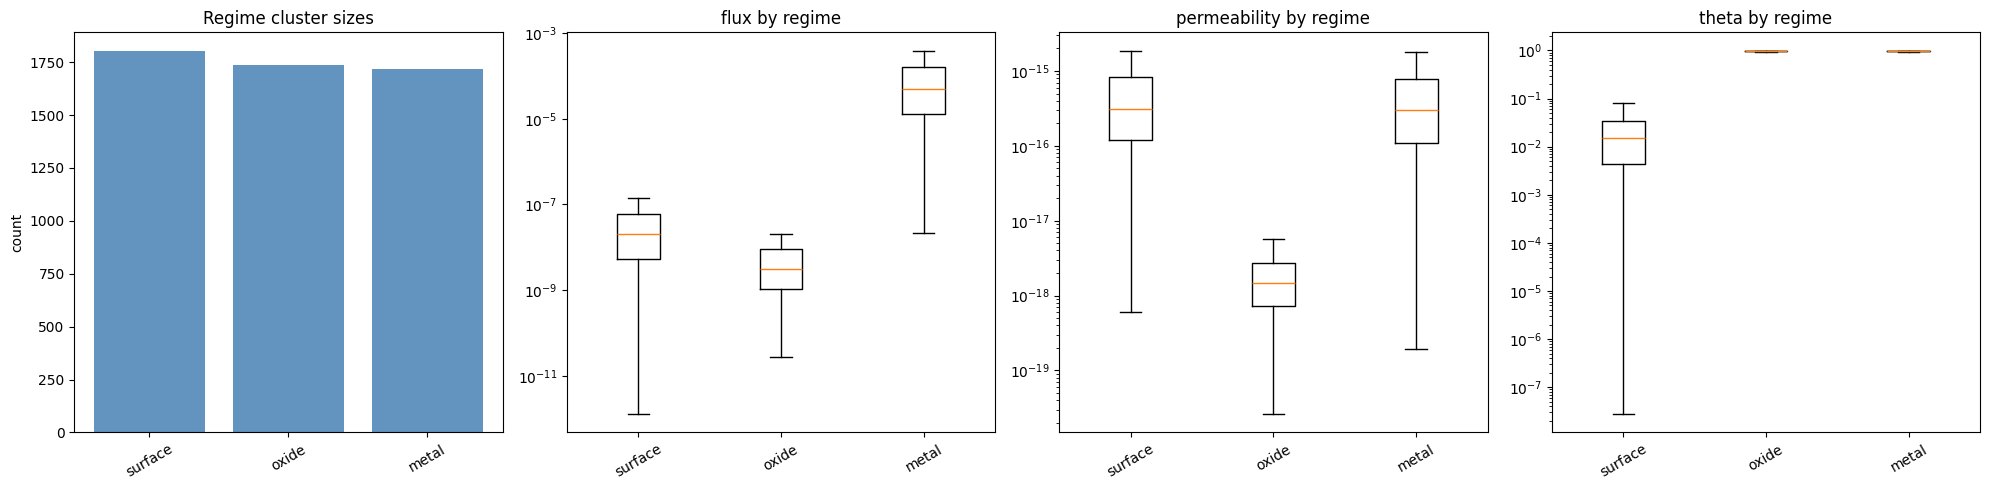


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting   metal  mixed  oxide  surface
regime                                             
metal                 108043   2047      0        0
oxide                      0   1006    792        0
surface                   18     32      0     1751

===== T = 1073 K =====


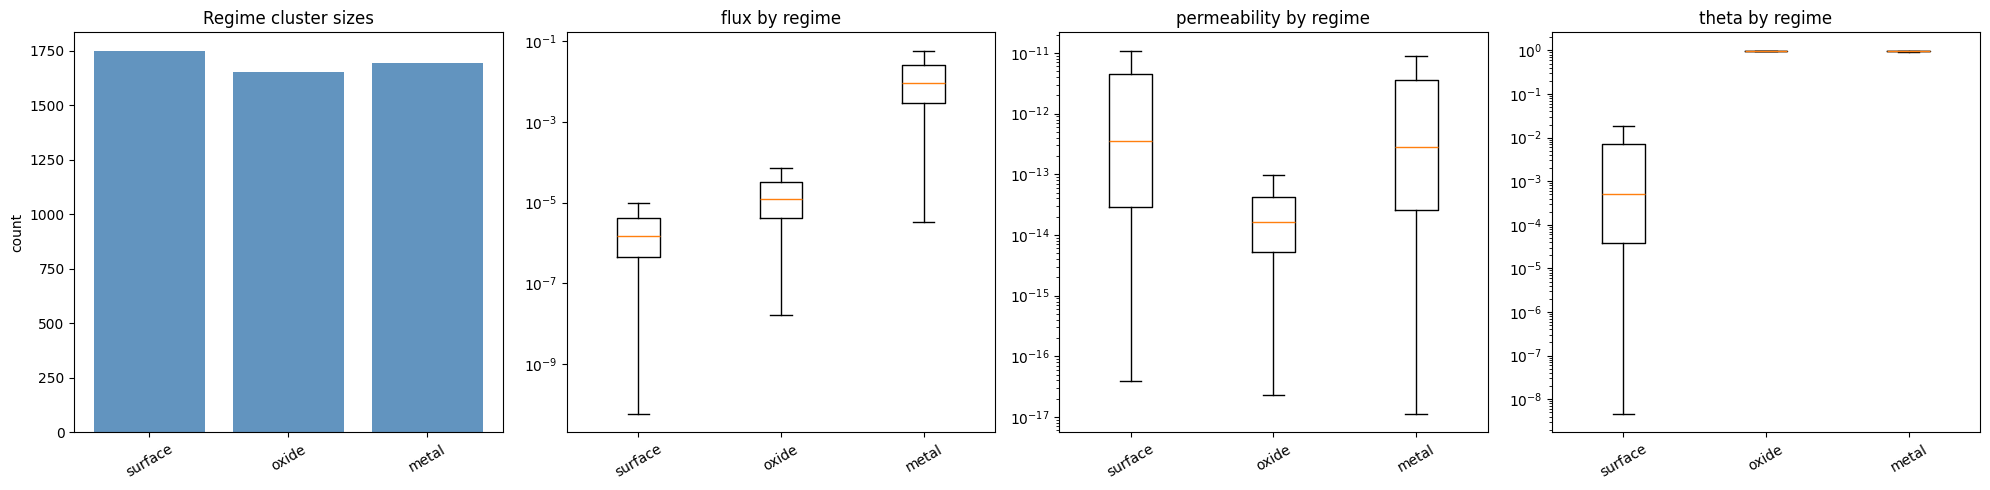


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  6909    818     10        0
oxide                     0    568   1205        0
surface                   5     10      0     1733

===== T = 1273 K =====


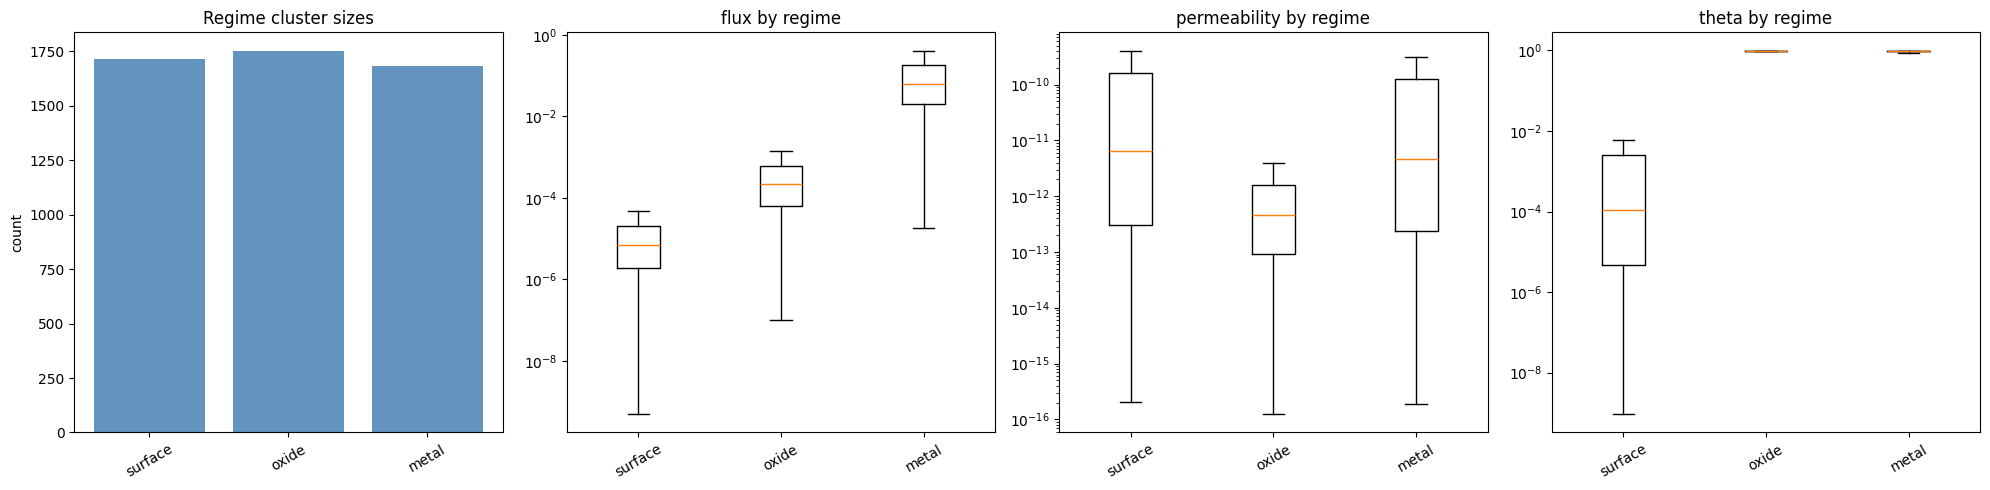


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  4444    669      6        0
oxide                     0    460   1396        0
surface                   4      2      0     1709


In [6]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    plot_regime_exploration(clusters_T[T], output_metrics=tuple(METRICS),
                            scan_df=pd.concat(scans_T[T].values(), ignore_index=True),
                            cross_col='system_rate_limiting')

## Phase 2 — Route B: given-data PAWN + delta, per temperature

Zero extra model evaluations. Each `(regime, metric)` entry carries the dummy-parameter noise
`floor`; `delta_over_floor <= 1` means the parameter is **not resolved**.

In [7]:
gd_T, tidy_T = {}, {}
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K =====")
    gd_T[T] = givendata_sensitivity_by_regime(
        clusters_T[T], PARAMS, output_metrics=METRICS, methods=('pawn', 'delta'),
        seed=SEED, log_metrics=LOG_METRICS_DEFAULT, n_dummy=20, verbose=True)
    tidy_T[T] = summarize_givendata(gd_T[T], PARAMS).assign(temperature_K=T)

tidy = pd.concat(tidy_T.values(), ignore_index=True)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)
print(f"\nrouteB_givendata.csv: {len(tidy)} rows")


===== T = 773 K =====
  [surface/flux] n= 1801  floor=0.100  top-δ: f_pinhole (0.221)
  [surface/permeability] n= 1801  floor=0.097  top-δ: H_sol_ox (0.299)
  [surface/theta] n= 1801  floor=0.087  top-δ: P_upstream (0.168)
  [oxide/flux] n= 1739  floor=0.097  top-δ: oxide_thickness (0.329)
  [oxide/permeability] n= 1739  floor=0.099  top-δ: H_sol_ox (0.354)
  [oxide/theta] n= 1739  floor=0.113  top-δ: H_eq (0.246)
  [metal/flux] n= 1719  floor=0.113  top-δ: K_s_ref (0.189)
  [metal/permeability] n= 1719  floor=0.105  top-δ: H_sol_ox (0.334)
  [metal/theta] n= 1719  floor=0.120  top-δ: P_upstream (0.216)

===== T = 1073 K =====
  [surface/flux] n= 1748  floor=0.101  top-δ: f_pinhole (0.208)
  [surface/permeability] n= 1748  floor=0.075  top-δ: H_sol_ox (0.583)
  [surface/theta] n= 1748  floor=0.117  top-δ: H_sol_ox (0.556)
  [oxide/flux] n= 1654  floor=0.099  top-δ: H_sol_ox (0.287)
  [oxide/permeability] n= 1654  floor=0.114  top-δ: H_sol_ox (0.491)
  [oxide/theta] n= 1654  floor=0.12

In [8]:
# delta/floor for EVERY parameter, no threshold. A hard filter creates an artificial
# cliff (0.99 hidden, 1.01 shown) and hides how wide the noise band is.
for T in TEMPERATURES:
    for reg in REGIME_LABELS:
        sub = (tidy[(tidy.metric == 'flux') & (tidy.temperature_K == T)
                    & (tidy.regime == reg)]
               .sort_values('delta_over_floor', ascending=False))
        floor = sub['floor'].iloc[0]
        n_res = int((sub.delta_over_floor > 1.0).sum())
        print(f"  T={T:.0f}K  {reg:8s} floor={floor:.3f}  ({n_res}/{len(sub)} above 1.0x)")
        for _, r_ in sub.head(6).iterrows():
            mark = '' if r_.delta_over_floor > 1.0 else '   <- at/below noise'
            print(f"        {r_.parameter:22s} delta={r_.delta:.3f}"
                  f"  ({r_.delta_over_floor:.2f}x){mark}")
    print()

  T=773K  surface  floor=0.100  (5/35 above 1.0x)
        f_pinhole              delta=0.221  (2.21x)
        k_diss_metal_ref       delta=0.177  (1.77x)
        P_upstream             delta=0.172  (1.71x)
        metal_thickness        delta=0.111  (1.11x)
        trap_vacancy_N_T       delta=0.101  (1.01x)
        D_ref                  delta=0.097  (0.97x)   <- at/below noise
  T=773K  oxide    floor=0.097  (7/35 above 1.0x)
        oxide_thickness        delta=0.329  (3.38x)
        H_sol_ox               delta=0.181  (1.86x)
        K_s_ref                delta=0.176  (1.81x)
        P_upstream             delta=0.139  (1.43x)
        f_pinhole              delta=0.108  (1.11x)
        crack_thickness_factor delta=0.100  (1.03x)
  T=773K  metal    floor=0.113  (6/35 above 1.0x)
        K_s_ref                delta=0.189  (1.67x)
        D_ref                  delta=0.171  (1.51x)
        trap_vacancy_E_b       delta=0.153  (1.35x)
        metal_thickness        delta=0.144  (1.27x

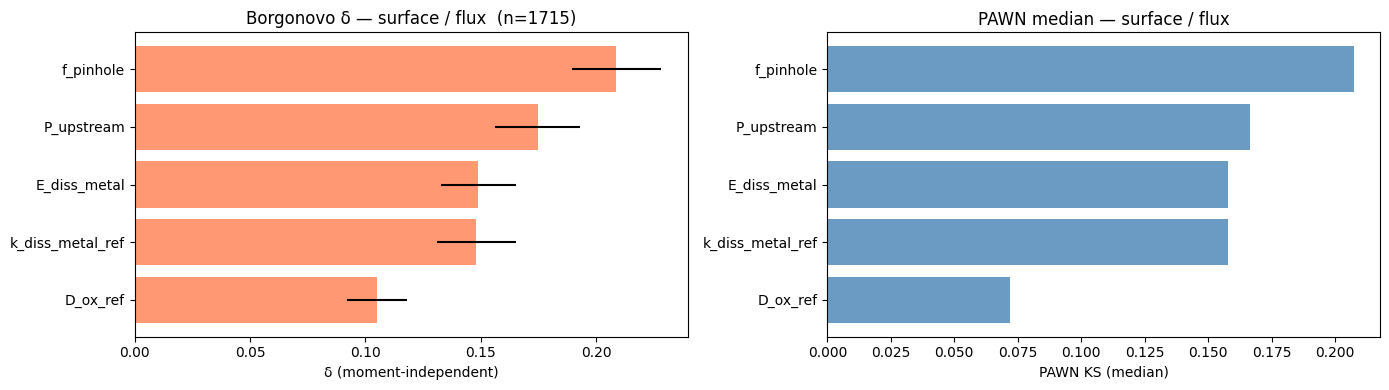

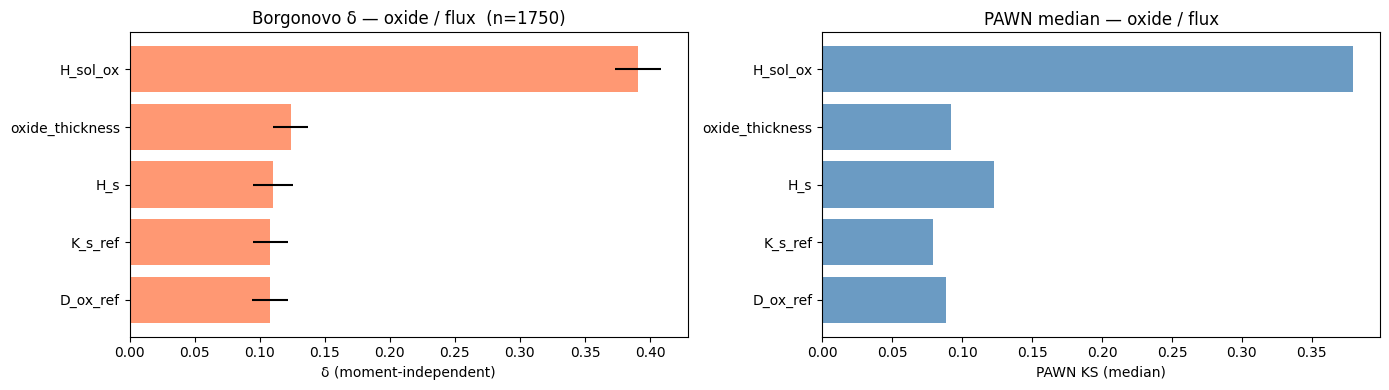

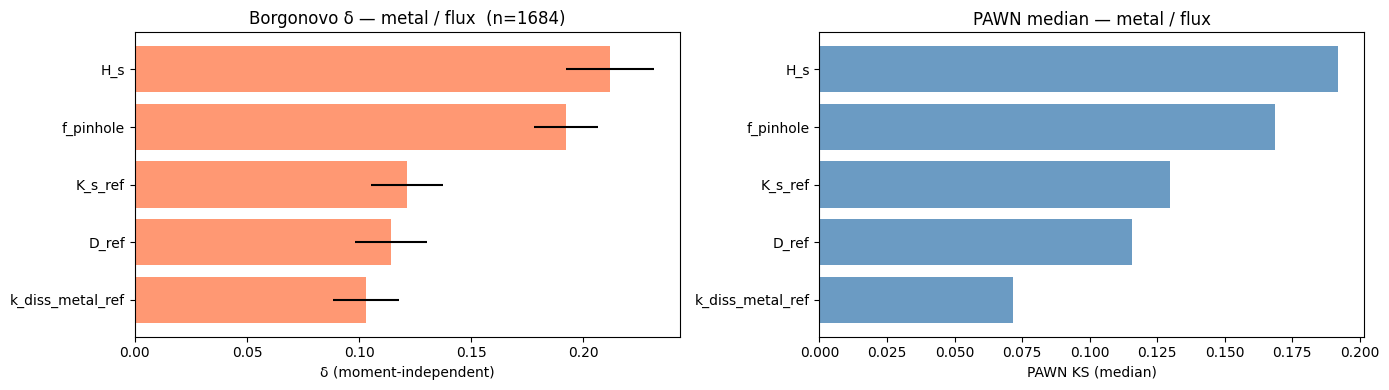

In [9]:
for reg in REGIME_LABELS:
    plot_givendata_results(gd_T[TEMPERATURES[-1]], reg, 'flux', PARAMS, top_n=5)

## Phase 2 (cont.) — regime geometry (highest temperature)

Clusters projected on their two strongest drivers. Dashed boxes are the 10-90 percentile band;
overlap is the reminder that regime boundaries are curved, not rectangular.

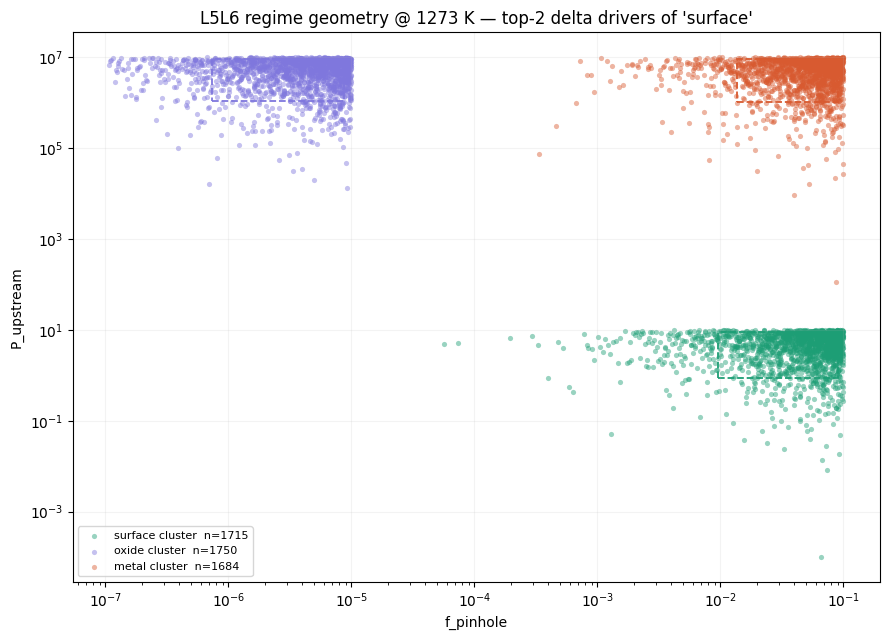

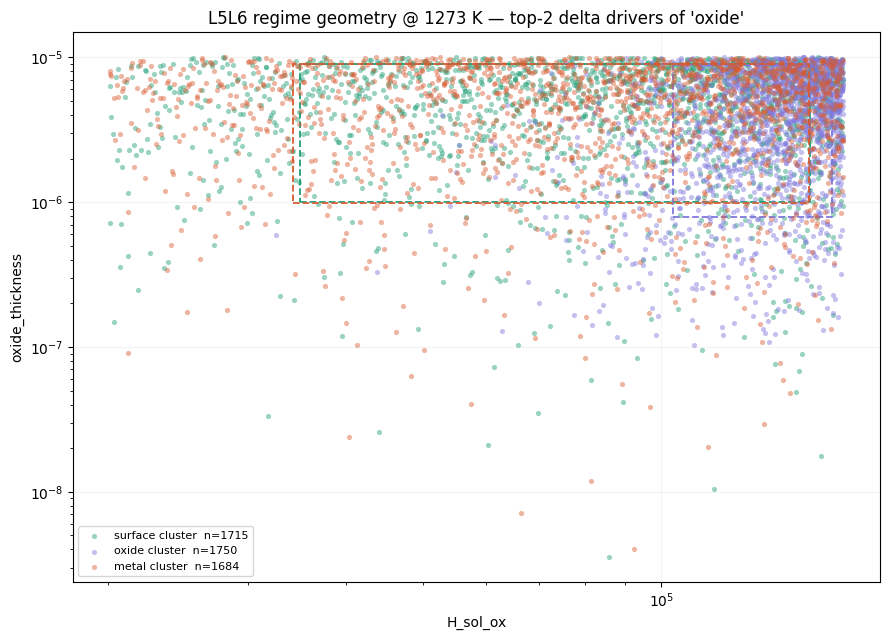

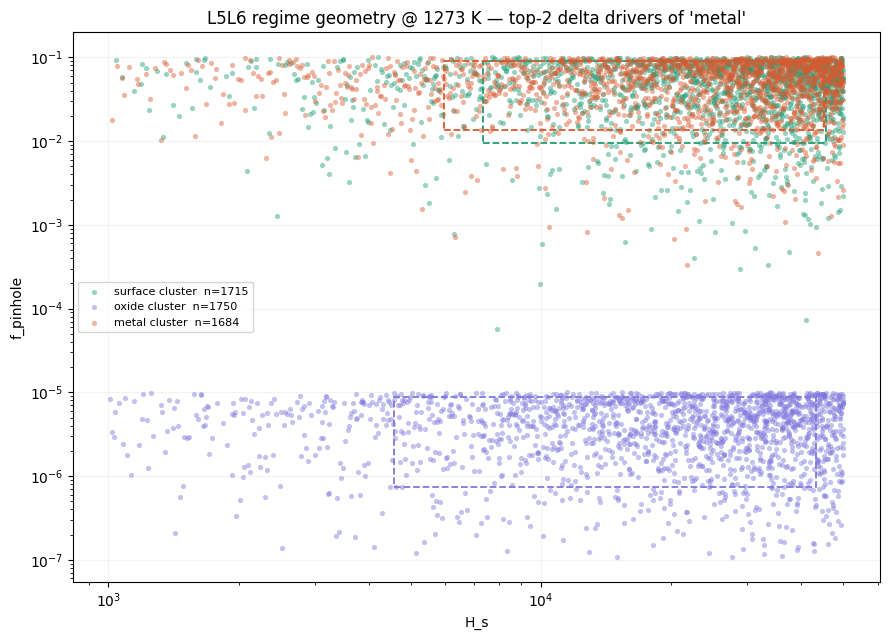

In [10]:
T_show = TEMPERATURES[-1]
def regime_topk(reg, k=TOP_K, metric='flux', T=None):
    """Top-k parameters for one regime at one temperature, ranked by Route-B delta."""
    T = T_show if T is None else T
    sub = tidy[(tidy.temperature_K == T) & (tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

for reg in REGIME_LABELS:
    plot_regime_geometry(clusters_T[T_show], axes=regime_topk(reg)[:2],
                         log_x=True, log_y=True,
                         title=f"L5L6 regime geometry @ {T_show:.0f} K — top-2 delta drivers of '{reg}'")

## Phase 3 — Cross-regime comparison, per temperature

Columns are column-normalised so each regime spans a full 0-1 scale; the small corner number is
the raw index. Exported `compare_*.csv` files are always raw.


===== T = 773 K — delta, log10(flux) =====


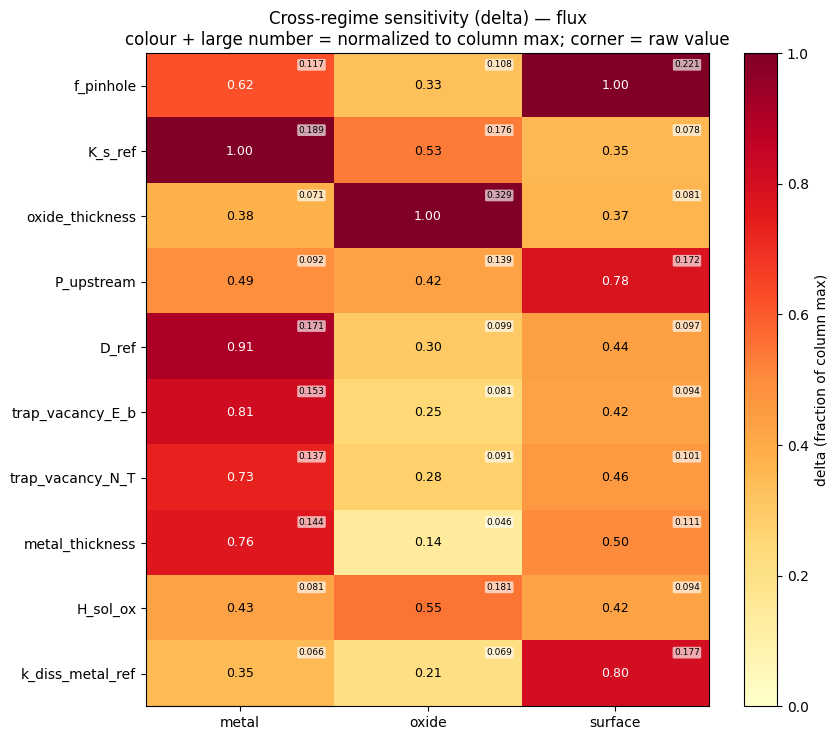


===== T = 1073 K — delta, log10(flux) =====


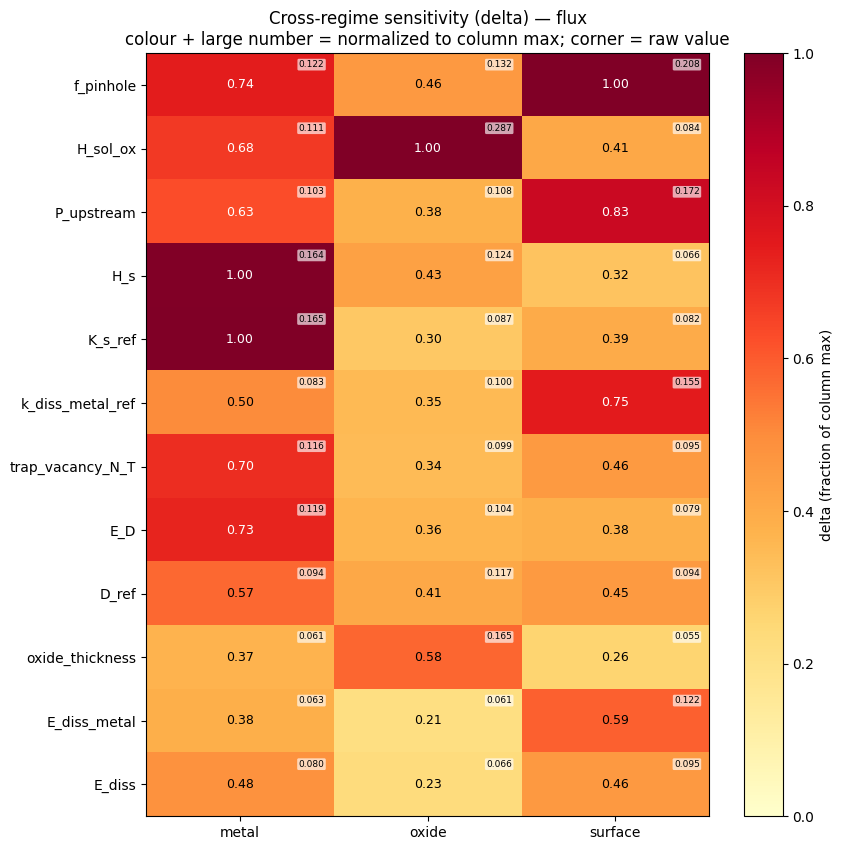


===== T = 1273 K — delta, log10(flux) =====


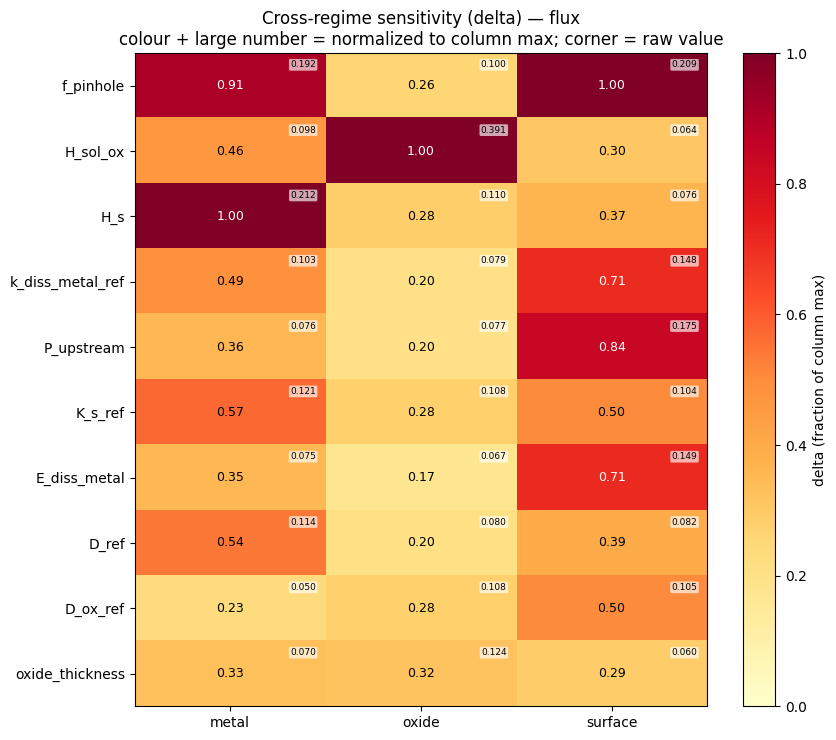

In [11]:
for T in TEMPERATURES:
    print(f"\n===== T = {T:.0f} K — delta, log10(flux) =====")
    plot_regime_comparison_heatmap(gd_T[T], 'flux', PARAMS, index='delta', top_union=5)
    for idx in ('delta', 'pawn_median'):
        for met in METRICS:
            mat = regime_comparison_matrix(gd_T[T], met, PARAMS, index=idx, top_union=5)
            if not mat.empty:
                mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}_T{int(T)}.csv"))

In [12]:
# How does each parameter's margin over the noise floor move with temperature?
# Unfiltered: every parameter appears at every T, so a value near 1.0 reads as
# "at the noise floor" instead of vanishing into a NaN that looks like missing data.
piv = (tidy[tidy.metric == 'flux']
       .pivot_table(index=['regime', 'parameter'], columns='temperature_K',
                    values='delta_over_floor'))
piv.columns = [f"{c:.0f}K" for c in piv.columns]
piv['best'] = piv.max(axis=1)

print("delta_over_floor for log10(flux) — ALL parameters, no threshold")
print("  1.0 = exactly at the dummy-parameter noise floor; higher = resolved\n")
for reg in REGIME_LABELS:
    fl = (tidy[(tidy.metric == 'flux') & (tidy.regime == reg)]
          .groupby('temperature_K')['floor'].first())
    print(f"[{reg}]  floor: " + "  ".join(f"{T:.0f}K={v:.3f}" for T, v in fl.items()))
    print(piv.loc[reg].sort_values('best', ascending=False).round(2).head(12).to_string())
    print()

piv.to_csv(os.path.join(RESULTS_DIR, "delta_over_floor_by_T.csv"))
print("saved delta_over_floor_by_T.csv")

delta_over_floor for log10(flux) — ALL parameters, no threshold
  1.0 = exactly at the dummy-parameter noise floor; higher = resolved

[surface]  floor: 773K=0.100  1073K=0.101  1273K=0.084
                  773K  1073K  1273K  best
parameter                                 
f_pinhole         2.21   2.06   2.50  2.50
P_upstream        1.71   1.71   2.09  2.09
E_diss_metal      0.92   1.21   1.78  1.78
k_diss_metal_ref  1.77   1.54   1.77  1.77
D_ox_ref          0.79   0.73   1.25  1.25
K_s_ref           0.78   0.81   1.25  1.25
E_D               0.52   0.79   1.25  1.25
metal_thickness   1.11   0.91   0.91  1.11
trap_vacancy_E_b  0.94   0.81   1.06  1.06
lattice_density   0.80   0.64   1.04  1.04
trap_vacancy_N_T  1.01   0.94   1.00  1.01
trap_carbide_N_T  0.66   0.70   1.00  1.00

[oxide]  floor: 773K=0.097  1073K=0.099  1273K=0.083
                      773K  1073K  1273K  best
parameter                                     
H_sol_ox              1.86   2.91   4.71  4.71
oxide_thickne

In [13]:
# theta is the metric temperature does NOT dominate — worth its own look
piv_t = (tidy[tidy.metric == 'theta']
         .pivot_table(index=['regime', 'parameter'], columns='temperature_K',
                      values='delta_over_floor'))
piv_t.columns = [f"{c:.0f}K" for c in piv_t.columns]
piv_t['best'] = piv_t.max(axis=1)
print("delta_over_floor for theta (surface coverage) — top 8 per regime\n")
for reg in REGIME_LABELS:
    print(f"[{reg}]")
    print(piv_t.loc[reg].sort_values('best', ascending=False).round(2).head(8).to_string())
    print()

delta_over_floor for theta (surface coverage) — top 8 per regime

[surface]
                 773K  1073K  1273K   best
parameter                                 
H_sol_ox         1.11   4.75  49.09  49.09
P_upstream       1.93   1.23   1.04   1.93
H_eq             1.84   0.87   0.61   1.84
K_eq_ref         1.67   1.04   0.90   1.67
oxide_thickness  1.28   0.77   0.64   1.28
k_diss_ref       1.27   1.02   0.86   1.27
E_diss           1.25   0.99   0.73   1.25
f_pinhole        1.19   1.00   0.79   1.19

[oxide]
             773K  1073K  1273K  best
parameter                            
P_upstream   1.42   1.47   2.28  2.28
H_eq         2.17   0.95   0.99  2.17
K_eq_ref     1.75   1.65   1.51  1.75
H_sol_ox     0.71   0.89   1.25  1.25
f_crack      1.00   1.17   0.93  1.17
D_ox_ref     0.75   1.12   0.96  1.12
E_D          0.79   0.82   1.08  1.08
f_gb_defect  0.93   1.07   0.88  1.07

[metal]
                  773K  1073K  1273K  best
parameter                                 
H_sol_ox  

In [14]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")

Saved CSV files under /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Guo_etal_2025/sa_results :
   compare_delta_flux_T1073.csv (0 KB)
   compare_delta_flux_T1273.csv (0 KB)
   compare_delta_flux_T773.csv (0 KB)
   compare_delta_permeability_T1073.csv (0 KB)
   compare_delta_permeability_T1273.csv (0 KB)
   compare_delta_permeability_T773.csv (0 KB)
   compare_delta_theta_T1073.csv (0 KB)
   compare_delta_theta_T1273.csv (0 KB)
   compare_delta_theta_T773.csv (0 KB)
   compare_pawn_median_flux_T1073.csv (0 KB)
   compare_pawn_median_flux_T1273.csv (0 KB)
   compare_pawn_median_flux_T773.csv (0 KB)
   compare_pawn_median_permeability_T1073.csv (0 KB)
   compare_pawn_median_permeability_T1273.csv (0 KB)
   compare_pawn_median_permeability_T773.csv (0 KB)
   compare_pawn_median_theta_T1073.csv (0 KB)
   compare_pawn_median_theta_T1273.csv (0 KB)
   compare_pawn_median_theta_T773.csv (0 KB)
   delta_over_floor_by_T.csv (9 KB)
   master_clusters.csv (14524 KB)
  